<a href="https://colab.research.google.com/github/Aarya718/VOIS-INTERNSHIP/blob/main/Healthcare_Analytics_for_Doctor_Visits_Completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Healthcare Analytics for Doctor Visit TIRTC

NAME : AARYA RAMCHANDRA TARPHE

AICTE STUDENT ID : STU66595b86dc18b1717132166



In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

## 1. Loading the dataset

In [ ]:

file_path = "1776250375-P2-Healthcare Analytics for Doctor Visits (1).csv"

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    df = pd.read_csv("/content/1776250375-P2-Healthcare Analytics for Doctor Visits (1).csv")

df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


## 2. Initial inspection of the data

In [ ]:

df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [ ]:

df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [ ]:

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 5190
Columns: 13


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [ ]:

df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [ ]:

missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

,0
Unnamed: 0,0
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0


In [ ]:

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## 3. Basic data preparation

The `Unnamed: 0` column works as a row identifier, so it is not required for the analysis. A copy of the data is used before removing this column.

In [ ]:

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


## 4. Univariate Analysis

### 4.1 Gender distribution

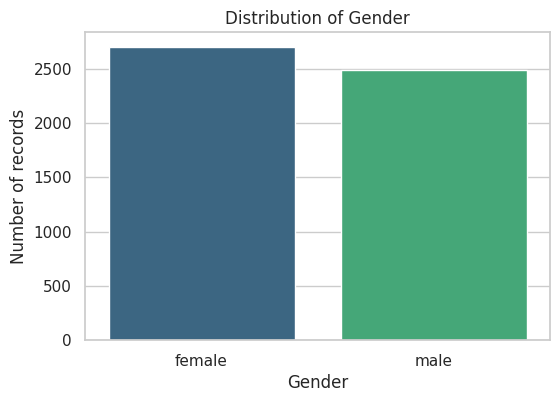

,count
gender,
female,2702
male,2488


In [ ]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="gender", hue="gender", palette="viridis", legend=False)
plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Number of records")
plt.show()

gender_counts

### 4.2 Age distribution

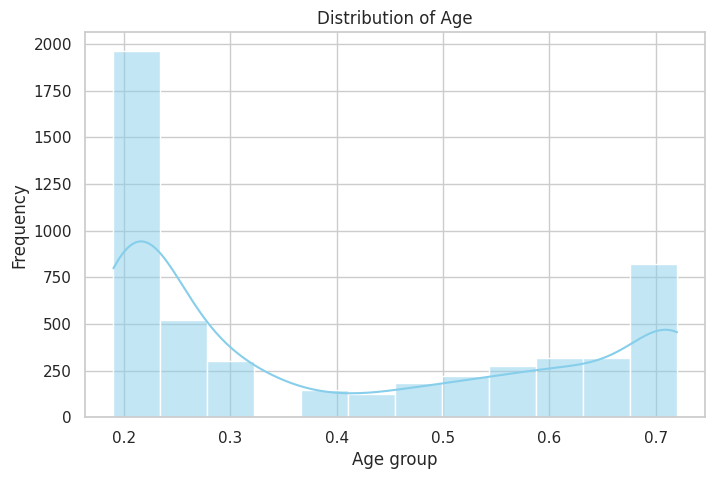

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", bins=12, kde=True, color="skyblue")
plt.title("Distribution of Age")
plt.xlabel("Age group")
plt.ylabel("Frequency")
plt.show()

### 4.3 Distribution of doctor visits

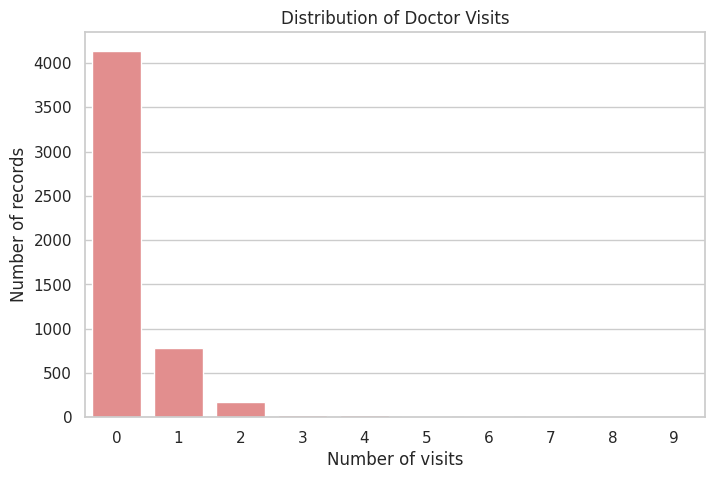

,count
visits,
0,4141
1,782
2,174
3,30
4,24
5,9
6,12
7,12
8,5


In [ ]:
visit_counts = df["visits"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="visits", color="lightcoral")
plt.title("Distribution of Doctor Visits")
plt.xlabel("Number of visits")
plt.ylabel("Number of records")
plt.show()

visit_counts

### 4.4 Illness score distribution

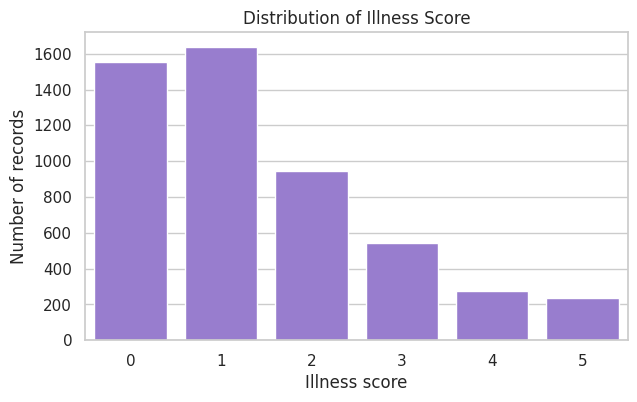

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="illness", color="mediumpurple")
plt.title("Distribution of Illness Score")
plt.xlabel("Illness score")
plt.ylabel("Number of records")
plt.show()

## 5. Bivariate Analysis

### 5.1 Average doctor visits by gender

,gender,count,mean,median,sum
0,female,2702,0.361954,0.0,978
1,male,2488,0.236334,0.0,588


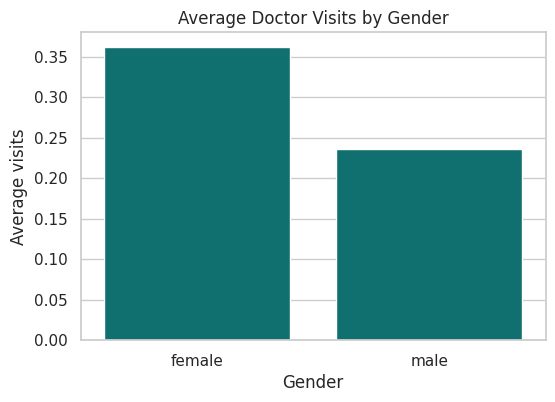

In [ ]:
gender_analysis = (
    df.groupby("gender")["visits"]
      .agg(["count", "mean", "median", "sum"])
      .reset_index()
)

display(gender_analysis)

plt.figure(figsize=(6, 4))
sns.barplot(data=gender_analysis, x="gender", y="mean", color="teal")
plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Average visits")
plt.show()

### 5.2 Illness score and average doctor visits

,illness,count,mean,median
0,0,1554,0.078507,0.0
1,1,1638,0.295482,0.0
2,2,946,0.403805,0.0
3,3,542,0.420664,0.0
4,4,274,0.576642,0.0
5,5,236,0.813559,0.0


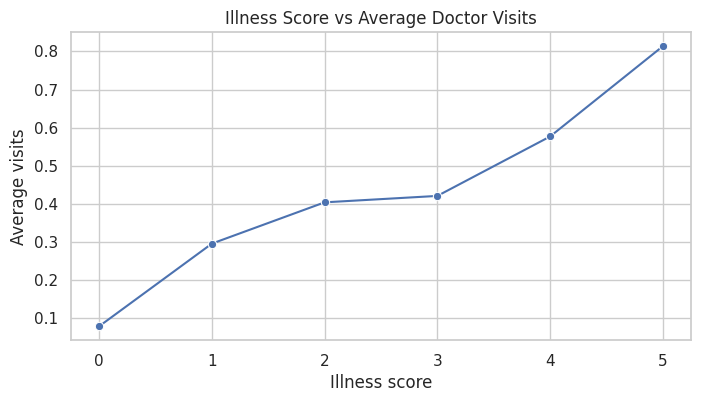

In [ ]:
illness_analysis = (
    df.groupby("illness")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

display(illness_analysis)

plt.figure(figsize=(8, 4))
sns.lineplot(data=illness_analysis, x="illness", y="mean", marker="o")
plt.title("Illness Score vs Average Doctor Visits")
plt.xlabel("Illness score")
plt.ylabel("Average visits")
plt.xticks(sorted(df["illness"].unique()))
plt.show()

### 5.3 Average doctor visits by health score

,health,average_visits
0,0,0.199273
1,1,0.335358
2,2,0.381166
3,3,0.417582
4,4,0.534759
5,5,0.530303
6,6,0.625000
7,7,0.918033
8,8,0.476190
9,9,0.656250


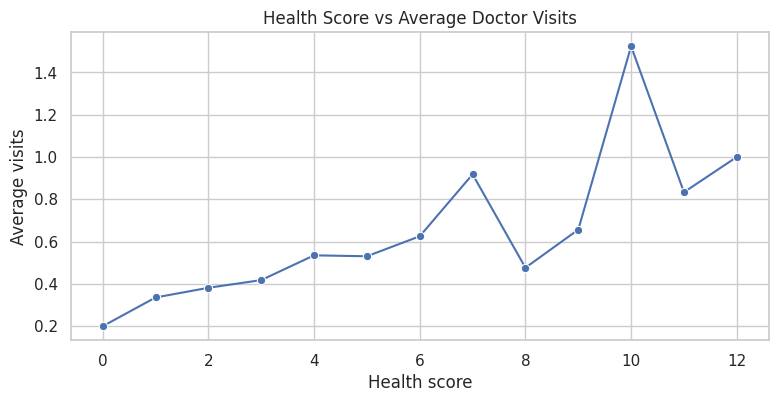

In [ ]:
health_analysis = (
    df.groupby("health")["visits"]
      .mean()
      .reset_index(name="average_visits")
)

display(health_analysis.head(15))

plt.figure(figsize=(9, 4))
sns.lineplot(data=health_analysis, x="health", y="average_visits", marker="o")
plt.title("Health Score vs Average Doctor Visits")
plt.xlabel("Health score")
plt.ylabel("Average visits")
plt.show()

## 6. Multivariate Analysis

### 6.1 Distribution of visits by gender

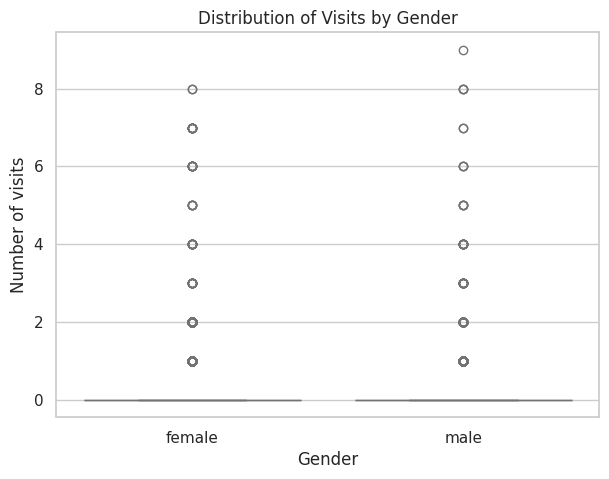

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="gender", y="visits", hue="gender", palette="pastel", legend=False)
plt.title("Distribution of Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of visits")
plt.show()

### 6.2 Age, visits and gender

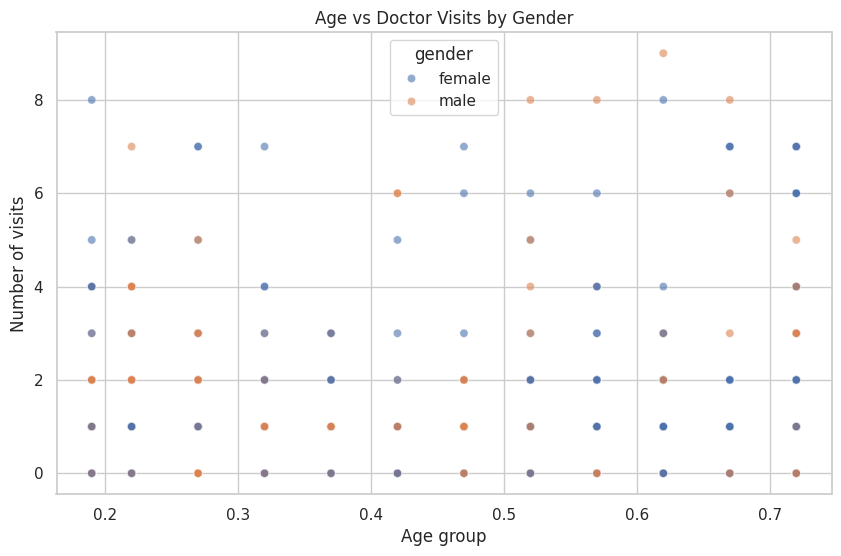

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="age",
    y="visits",
    hue="gender",
    alpha=0.6
)
plt.title("Age vs Doctor Visits by Gender")
plt.xlabel("Age group")
plt.ylabel("Number of visits")
plt.show()

### 6.3 Income and doctor visits

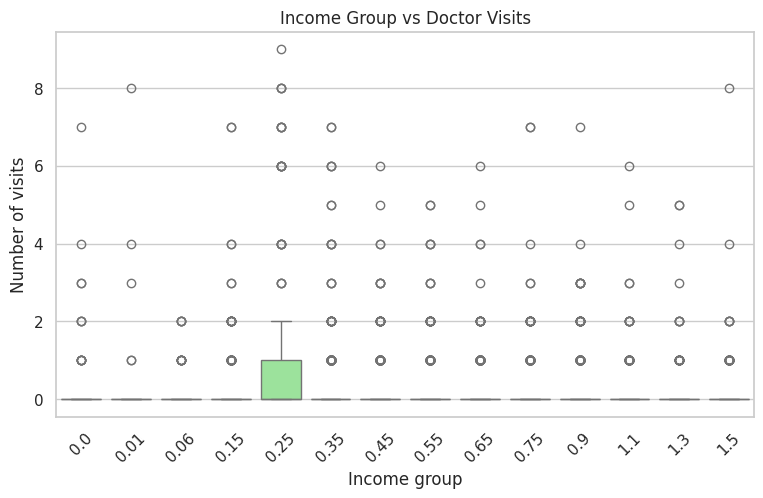

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="income", y="visits", color="lightgreen")
plt.title("Income Group vs Doctor Visits")
plt.xlabel("Income group")
plt.ylabel("Number of visits")
plt.xticks(rotation=45)
plt.show()

### 6.4 Chronic illness and doctor visits

,nchronic,lchronic,count,mean
0,no,no,2493,0.191737
1,no,yes,605,0.603306
2,yes,no,2092,0.345602


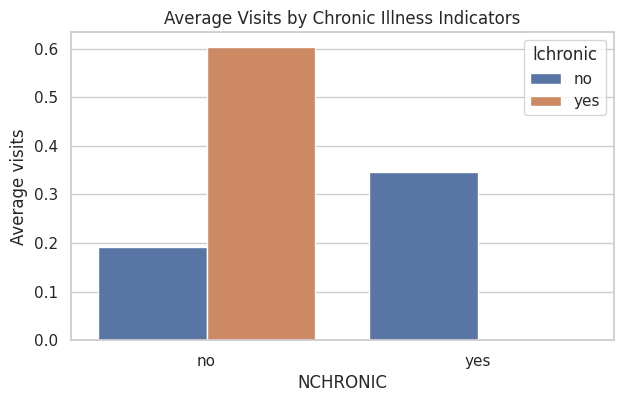

In [ ]:
chronic_summary = (
    df.groupby(["nchronic", "lchronic"])["visits"]
      .agg(["count", "mean"])
      .reset_index()
)

display(chronic_summary)

plt.figure(figsize=(7, 4))
sns.barplot(
    data=chronic_summary,
    x="nchronic",
    y="mean",
    hue="lchronic"
)
plt.title("Average Visits by Chronic Illness Indicators")
plt.xlabel("NCHRONIC")
plt.ylabel("Average visits")
plt.show()

## 7. Correlation analysis

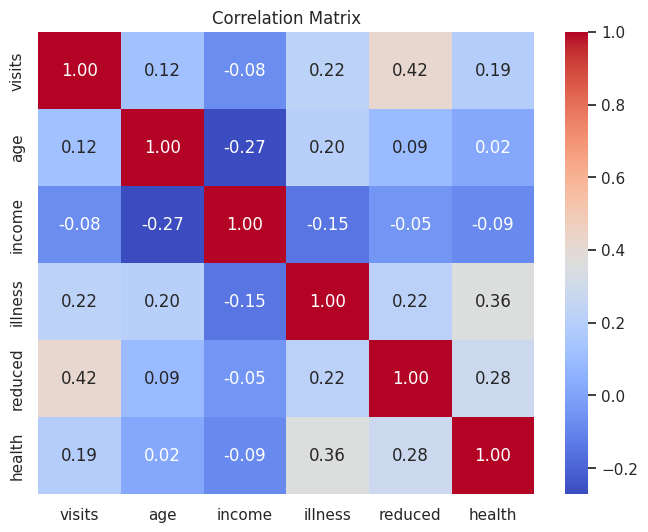

,visits
visits,1.000000
reduced,0.418954
illness,0.223552
health,0.193272
age,0.124537
income,-0.076840


In [ ]:
numeric_columns = [
    "visits", "age", "income", "illness", "reduced", "health"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

correlation_matrix["visits"].sort_values(ascending=False)

## 8. Key observations

The following points can be checked from the tables and charts produced above:

- The dataset contains records of doctor visits along with demographic and health-related information.
- Doctor visit counts are concentrated around the lower visit values, while a smaller number of records have higher visit counts.
- Gender-wise and illness-wise averages help compare the number of visits across different groups.
- The illness, health and reduced-activity variables can be used to study how health conditions are associated with doctor visits.
- The correlation matrix provides a quick view of the linear relationship between numerical variables. Correlation does not by itself prove causation.

The exact values should be read from the outputs generated by the notebook.

## 9. Conclusion

This exploratory analysis gives an overview of the factors available in the healthcare dataset and their relationship with doctor visits. Charts such as count plots, box plots, scatter plots and the correlation heatmap make the data easier to understand.

Further work could include building a predictive model for doctor visits, comparing different machine learning algorithms and evaluating the model using suitable metrics.